### Import the files

In [1]:
from deeplogger.download_data import *   

##path_to_data, files = download_VALTER_borehole('MB8')
path_to_data, files = download_VALTER_borehole('MB3')


In [2]:
# assign the "path_to_data" the path where MB3 was already downloaded       
#path_to_data = "/Users/palomaperritaz/deeplogger/data/MB3/"
# go into a directory and make a list of the files that are in there

#files.sort()




In [3]:
# Q: How can I load an image with python using the numpy library?
# A: https://stackoverflow.com/questions/7762948/how-to-convert-an-rgb-image-to-numpy-array

# write a function that takes in a 2D array, which is an image, and runs a smoothing filter
# on it. The function should return the smoothed image. The smoothing filter should be a
# 3x3 kernel with all values equal to 1/9. The function should also take in a parameter

#def smooth_image(image, kernel_size=3):
    # create a kernel with all values equal to 1/9
    #kernel = np.ones((kernel_size, kernel_size)) / kernel_size**2
    # apply the kernel to the image
    #smoothed_image = convolve2d(image, kernel, mode='same')
    #return smoothed_image



### Import the necessary functions to read the data
showing the "path_to_data" allows to make sure that it is well downloaded in your own computer, without any error.
Then import the necessary functions to read the ATV and OTV data (importLASv3.py). The star allows to import all the functions from the file.


In [2]:
from deeplogger.importLASv3 import *
from deeplogger.download_data import download_VALTER_borehole
#if the folder is downloaded for the first time, these are the commands to use
##file_atv_am = files[0] #am for the amplitude file which covers a maximum depth of borehole MB8
##file_atv_tt = files[2] #tt for the travel time file which covers a maximum depth of borehole MB8

#Borehole MB3
    #file_atv_am =files[10] #am for the amplitude file for 0 to 120m of borehole MB3
    #file_atv_tt = files[5] #tt for the amplitude file for 0 to 120m of borehole MB3
    ##sharp transition between 119.25 and 119.75m
    
    #file_atv_am =files[4] #am for the amplitude file for 104 to 132m of borehole MB3
    #file_atv_tt = files[1] #tt for the amplitude file for 104 to 132m of borehole MB3 there are no structures visible in this depth range



#file_atv_am =files[8] #am for the amplitude file for 137 to 146m of borehole MB3
#file_atv_am =files[9] #am for the amplitude file for 137 to 146m of borehole MB3
#file_atv_tt =files[0] #tt for the travel time file for 137 to 146m of borehole MB3
#file_atv_tt =files[3] #tt for the travel time file for 137 to 146m of borehole MB3


file_atv_tt =files[6] #tt for the travel time file for 137 to 152m of borehole MB3
file_atv_am =files[2] #am for the amplitude file for 137 to 152m of borehole MB3




#if the folder has already been downloaded, use the commands showed as following
#path_to_data = '/Users/palomaperritaz/deeplogger/data/MB8/'
#file_atv_tt = 'MB8_SGR_DEV_ATV_Travel_timecent_up_20210311.las' #tt for travel time
#file_atv_am =  'MB8_SGR_DEV_ATV_Ampl_cent_up_20210311.las' #am for amplitude

### Read and prepare the data

### Load the ATV Data
The following functions allow to load the OTV and ATV data and to remove the NaN values. The depth range can be manually changed. These are then plotted with "imshow" for the OTV and plot_atv for the travel time and amplitude. Such process allows to compare the quality of the data, assess the noise level (specially in atv images), detect potential structures, as well as to note a potential depth correction from the OTV to the ATV data. 

/Users/palomaperritaz/deeplogger/venv/lib/python3.11/site-packages/pandas/core/internals/managers.py:1715: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr


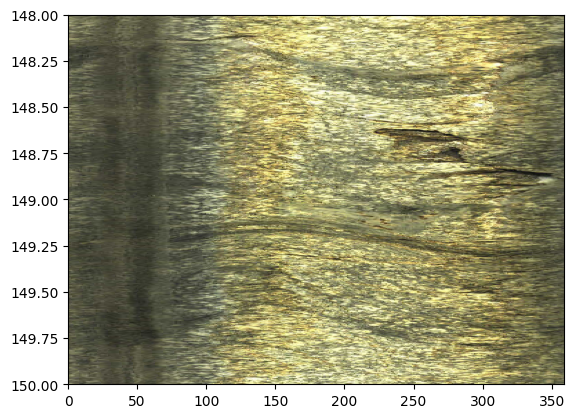

In [3]:
#Load OTV data and remove the empty measurements
from matplotlib import pyplot as plt

from deeplogger.image_processing import *
file_name = files[7]
depth_OTV = get_depth_only(file_name=files[7],
               data_path=path_to_data)

depth_subset, data_subset, index = get_data_subset_from_depth_range(file_name=files[7],
                                                                    data_path=path_to_data,
                                                                    data_type='otv',
                                                                    depth_range=[148, 150])
data_subset = replace_empty_measurements(data_subset, 0)
plt_OTV = plt.imshow(data_subset, aspect='auto', extent=[0, 359, 150, 148])


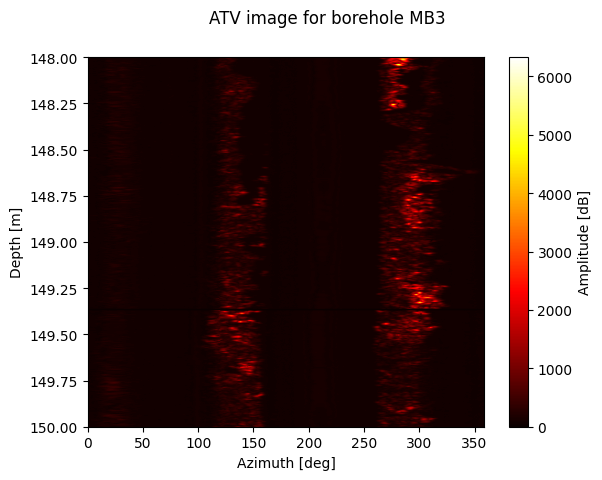

In [4]:
from deeplogger.plotting import *
#import the data and select a range of depth (amplitude)

depth_ATV_am = get_depth_only(file_name=file_atv_am, #you can also just put the number of the data location in the files list, which is "files[10]" for the amplitude MB3 and "files[5]" for the travel time MB3
               data_path=path_to_data)

depth_subset_ATV_am, data_subset_ATV_am, index = get_data_subset_from_depth_range(file_name=file_atv_am,
                                                                    data_path=path_to_data,
                                                                    data_type='atv',
                                                                    depth_range=[148, 150])
#take-off the zero values within the data subset
data_subset_ATV_am = replace_empty_measurements(data_subset_ATV_am, 0)
from deeplogger.plotting import *
plt_ATV_am =plot_atv_am(data_subset_ATV_am, figure_limits=[0, 359,150, 148], cmap='hot', title= "ATV image for borehole MB3")



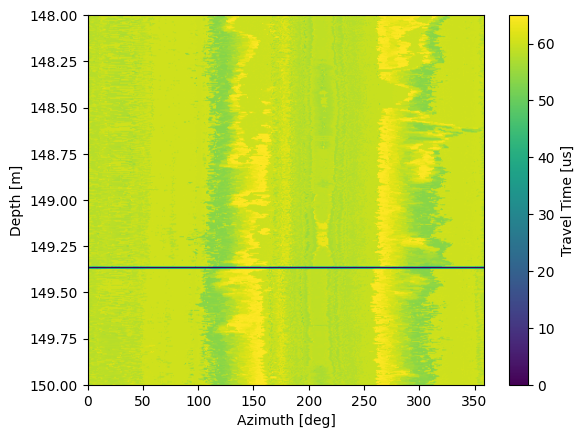

In [5]:
                                                                   
#same but with travel time
depth_ATV_tt = get_depth_only(file_name=file_atv_tt,
               data_path=path_to_data)

depth_subset_ATV_tt, data_subset_ATV_tt, index = get_data_subset_from_depth_range(file_name=file_atv_tt,
                                                                    data_path=path_to_data,
                                                                    data_type='atv',
                                                                    depth_range=[148, 150])
#take-off the zero values
data_subset_ATV_tt = replace_empty_measurements(data_subset_ATV_tt, 0)
plt_ATV_tt = plot_atv_tt(data_subset_ATV_tt, figure_limits=[0, 359, 150, 148], cmap='viridis')

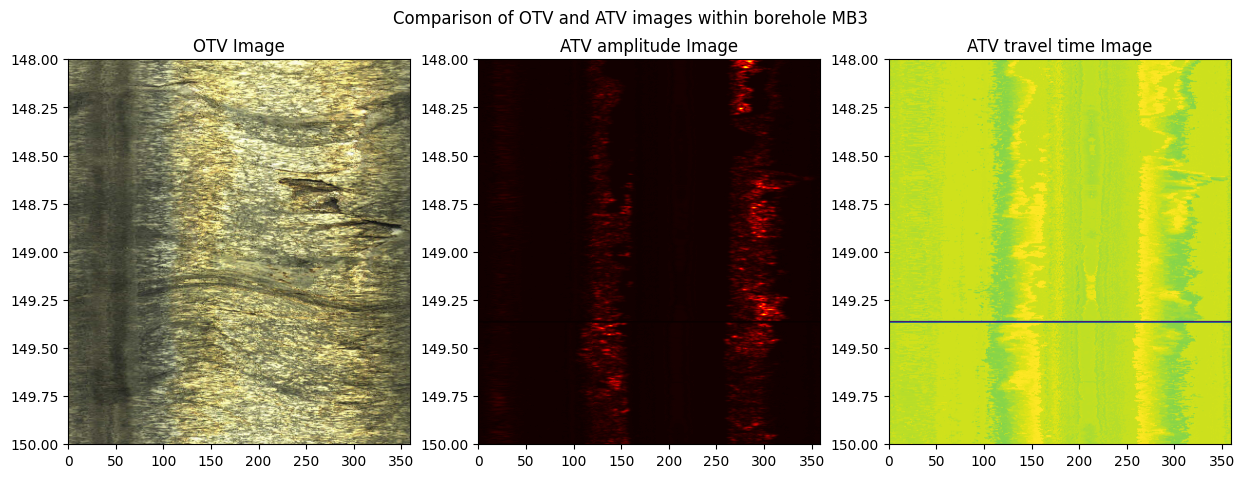

In [6]:
#compare the three plots ad note the differences
import matplotlib.pyplot as plt

# Assuming you have defined your plot_atv function
# and data_subset_ATV_am, data_subset_ATV_tt are your data subsets

# Create a figure and three subplots (1 row, 3 columns)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # Adjust the figure size as needed

# Plot the first image with the colormap 'viridis'
plt_OTV = axs[0].imshow(data_subset, aspect='auto', extent=[0, 359, 150, 148], cmap='viridis')
# Plot the second image with the default colormap (original)
plt_ATV_am = axs[1].imshow(data_subset_ATV_am, aspect='auto', extent=[0, 359, 150, 148], cmap='hot')
# Plot the third image with the default colormap (original)
plt_ATV_tt = axs[2].imshow(data_subset_ATV_tt, aspect='auto', extent=[0, 359, 150, 148], cmap='viridis')

# Add titles to each subplot
axs[0].set_title('OTV Image')
axs[1].set_title('ATV amplitude Image')
axs[2].set_title('ATV travel time Image')

# Add a common title for the entire figure
fig.suptitle('Comparison of OTV and ATV images within borehole MB3')

# Show the figure
plt.show()



By focusing on borehole MB3, where there is a sharp transition from a rather intact to a fractured zone at 119.25 m, it is possible to note that there is indeed a shift in depth of -0.5 m from the OTV to the ATV images. (See Fig.1)

It is important to note that depending on the colourmap chosen, the features on the ATV images are more or less visible. The "viridis" colormap is the one that allows to see the most features for the travel time images, whereas the contrasts in amplitude are better seen with the 'hot' colormap (see contrast Fig.1 and Fig.2).

<img src="/Users/palomaperritaz/Desktop/comparison_MB3_118_120.png" alt="Alternative text" />
(Fig. 1: Comparison of OTV and ATV images within borehole MB3, with a "viridis" colormap.)

<img src="/Users/palomaperritaz/Desktop/comparison_MB3_118_120_hot.png" alt="Alternative text" />
(Fig. 2: Comparison of OTV and ATV images within borehole MB3, with a "hot" colormap)




Fore borehle MB3, a certain depth were visible structures within OTV images was selected, reported to the ATV images in order to proceed to a comparison. In our case, depths between 137 and 146 m were selected, specifically from 148 to 150mm as shown in Figure 3. The ATV images contain lot of noise, which is why it is important to apply a filtering process. Tests on such methods are displayed and explaines in the following sections, allowing to assess the most appropriate one for this specific case.


<img src="/Users/palomaperritaz/Desktop/comparison_MB3_148_150_mix.png" alt="Alternative text" />
(Fig. 2: Comparison of OTV and ATV images within borehole MB3, with an applied "hot" colormap on amplitude and "viridis" colormap on travel time images.)



### Apply the filtering

#### SVD filtering
It is one of the most well-used tools for data processing. It is defined as reduction tool used for high dimensional and resolution data. The SVD will reduce it into the key features which allow to describe and analyse the data.
The singular value decomposition processes a matrix and outputs it into 3 different matrices. Each matrix has a constraint. The SVD theorem says it’s always possible to decompose a real (real =/complex numbers) matrix into these 3, as well as re-transpose. U: Left singular vectors ; R: diagonal matrix, it has 0 everywhere except for the diagonal, where there are, what are called, singular values. These are sorted in the decreasing order. V:  Right singular vectors 
U and V are column orthonormal. 
 
In this case, SVD filtering is applied to the ATV data. The function remove_svd allows to remove the svd part of the data. The low_s and high_s parameters allow to set the limits of the svd to remove. The svd_decomp variable allows to plot the svd part of the data.

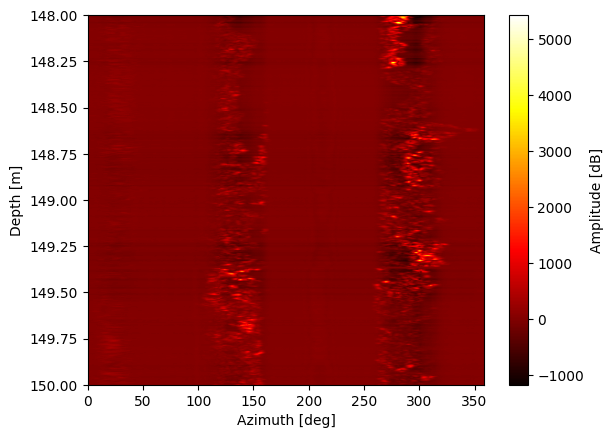

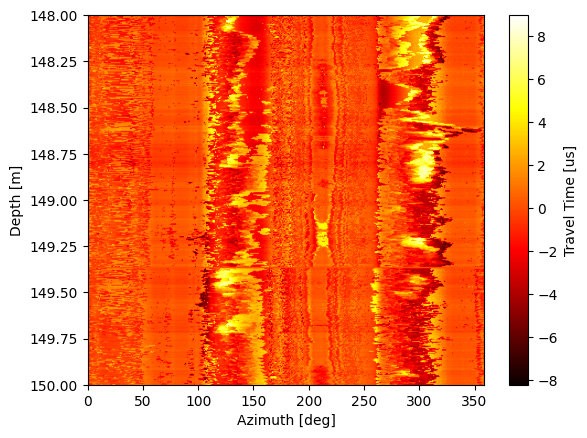

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='Azimuth [deg]', ylabel='Depth [m]'>)

In [7]:
from deeplogger.image_processing import *
from deeplogger.plotting import *


# Apply SVD and plot the filtered data
# function returns the input data without the svd part and the svd part that is removed
# you can set the limits of the svd to remove by setting the low_s and high_s parameters
data_subset_svd_am = data_subset_svd_am, svd_decomp_am = remove_svd(data_subset_ATV_am, low_s=0, high_s=1)
# plot the data without the svd part
plot_atv_am(data_subset_svd_am, figure_limits=[0, 359, 150, 148])

##same with the travel time data 
data_subset_svd_tt = data_subset_svd_tt, svd_decomp_tt = remove_svd(data_subset_ATV_tt, low_s=0, high_s=1)
# plot the data without the svd part
plot_atv_tt(data_subset_svd_tt, figure_limits=[0, 359, 150, 148])

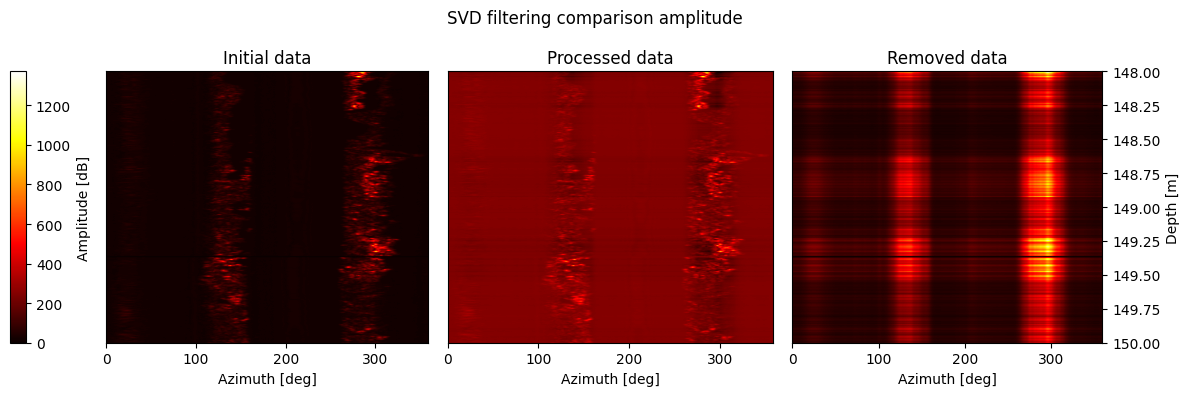

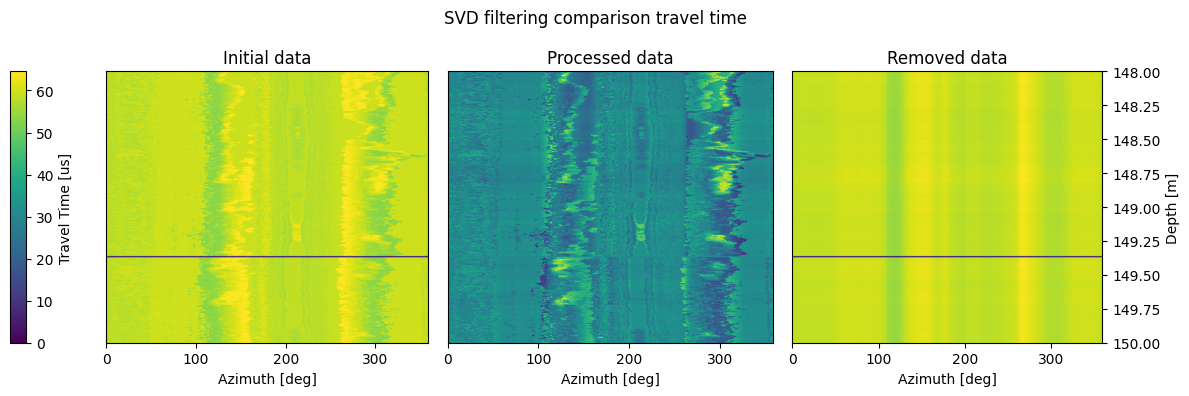

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: title={'center': 'Initial data'}, xlabel='Azimuth [deg]'>,
        <Axes: title={'center': 'Processed data'}, xlabel='Azimuth [deg]'>,
        <Axes: title={'center': 'Removed data'}, xlabel='Azimuth [deg]', ylabel='Depth [m]'>],
       dtype=object))

In [8]:
#plot a comparison of the image with and without the svd part, as well as the removed svd part
plot_comparison_am(data_subset_ATV_am,
                data_subset_svd_am,
                svd_decomp_am,   
                figure_limits=[0, 359, 150, 148], 
                title='SVD filtering comparison amplitude')
plot_comparison_tt(data_subset_ATV_tt,
                data_subset_svd_tt,
                svd_decomp_tt,   
                figure_limits=[0, 359, 150, 148], 
                title='SVD filtering comparison travel time',
                cmap='viridis')

#### High-pass filtering
High-pass filtering allows to remove the low frequencies from the data, in order to sharpen the edges of the features from the ATV images. The function remove_high_pass allows to remove the high pass part of the data. The low_f and high_f parameters allow to set the limits of the high pass to remove. The high_pass variable allows to plot the high pass part of the data.

The high pass 2D kernel function allows to create a 2D kernel with a high pass filter. The kernel of the high pass filter is designed to increase the brightness of the center pixel relative to neighboring pixels. It is then applied to the data with the convolve 2d function. The function returns the input data without the high pass part.  


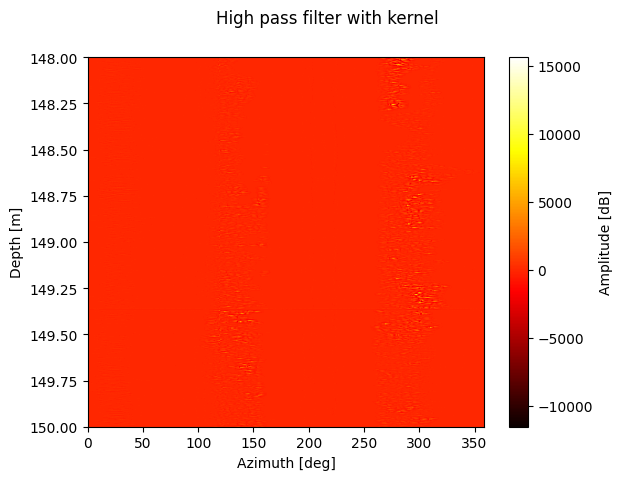

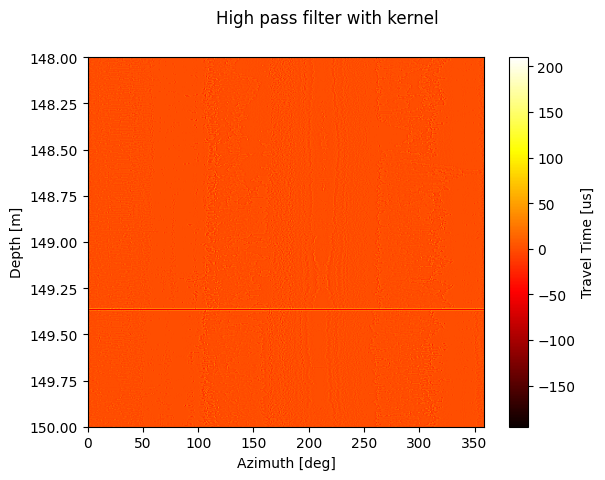

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='Azimuth [deg]', ylabel='Depth [m]'>)

In [9]:
#apply the high pass filter with kernel and plot the result
hpass_am = high_pass_2D_kernel(data_subset_ATV_am)
plot_atv_am(hpass_am,
         cmap='hot',
         figure_limits=[0, 359, 150, 148], 
         title='High pass filter with kernel')
#same for travel time
hpass_tt = high_pass_2D_kernel(data_subset_ATV_tt)
plot_atv_tt(hpass_tt,
         cmap='hot',
         figure_limits=[0, 359, 150, 148], 
         title='High pass filter with kernel')




The high-pass filter with FFT allows to remove the low frequencies from the data, in order to sharpen the edges of the features from the ATV images. The function remove_high_pass allows to remove the high pass part of the data. The low_f and high_f parameters allow to set the limits of the high pass to remove. The high_pass variable allows to plot the high pass part of the data.

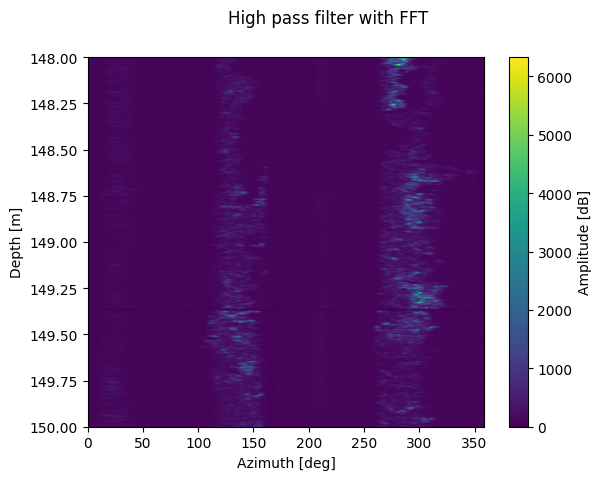

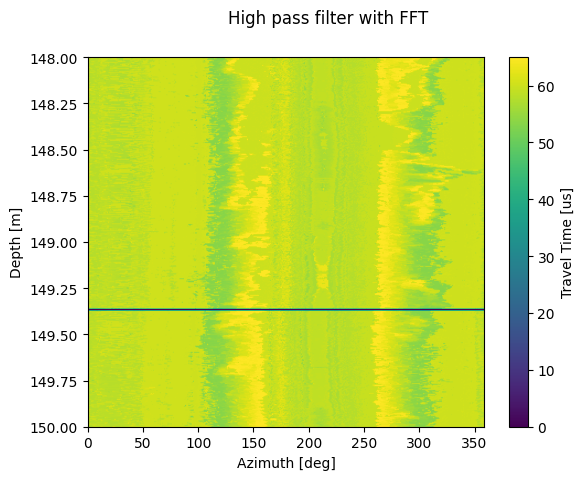

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='Azimuth [deg]', ylabel='Depth [m]'>)

In [10]:
#Apply the high-pass filter with fft and plot the result
hpass_fft = high_pass_FFT_2D(data_subset_ATV_am, cutoff_frequency=0.1)
plot_atv_am(hpass_fft,
         cmap='viridis',
         figure_limits=[0, 359, 150, 148], 
         title='High pass filter with FFT')

#same for travel time
hpass_fft = high_pass_FFT_2D(data_subset_ATV_tt, cutoff_frequency=0.1)
plot_atv_tt(hpass_fft,
         cmap='viridis',
         figure_limits=[0, 359, 150, 148], 
         title='High pass filter with FFT')

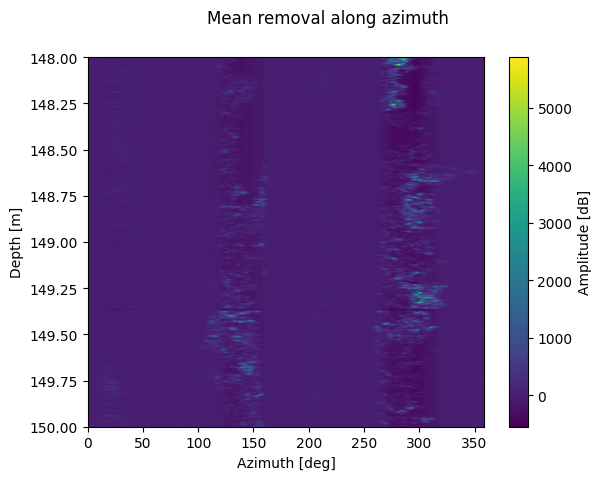

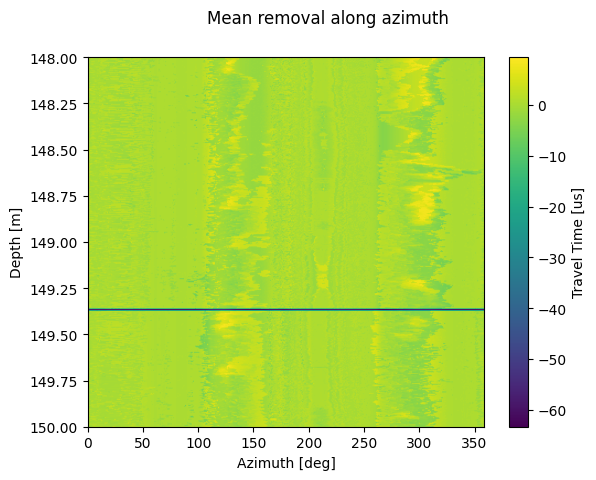

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='Azimuth [deg]', ylabel='Depth [m]'>)

In [11]:
#calculate the mean removal for both amplitude and travel time, then plot it

mean_removal_x, removed_data = remove_mean(data_subset_ATV_am, axis=0)
plot_atv_am(mean_removal_x,
         cmap='viridis',
         figure_limits=[0, 359, 150, 148], 
         title='Mean removal along azimuth')

mean_removal_x, removed_data = remove_mean(data_subset_ATV_tt, axis=0)
plot_atv_tt(mean_removal_x,
         cmap='viridis',
         figure_limits=[0, 359, 150, 148], 
         title='Mean removal along azimuth')


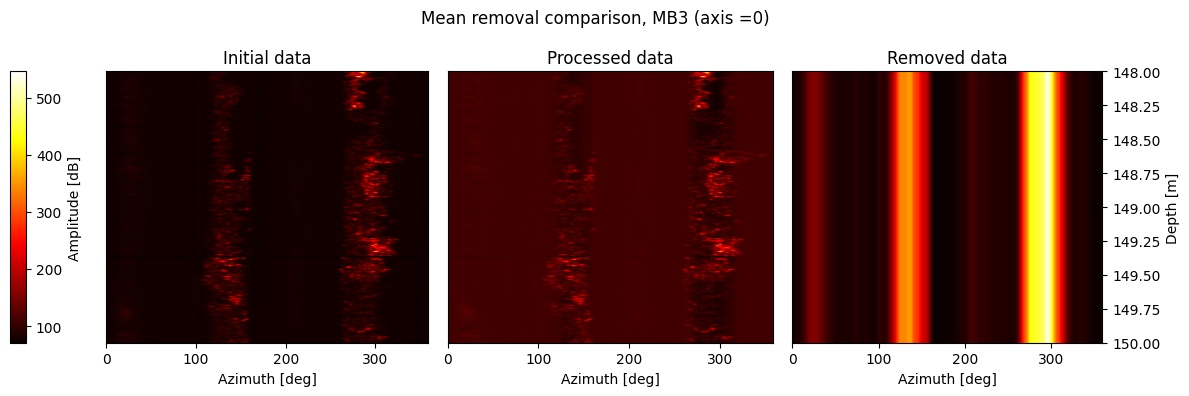

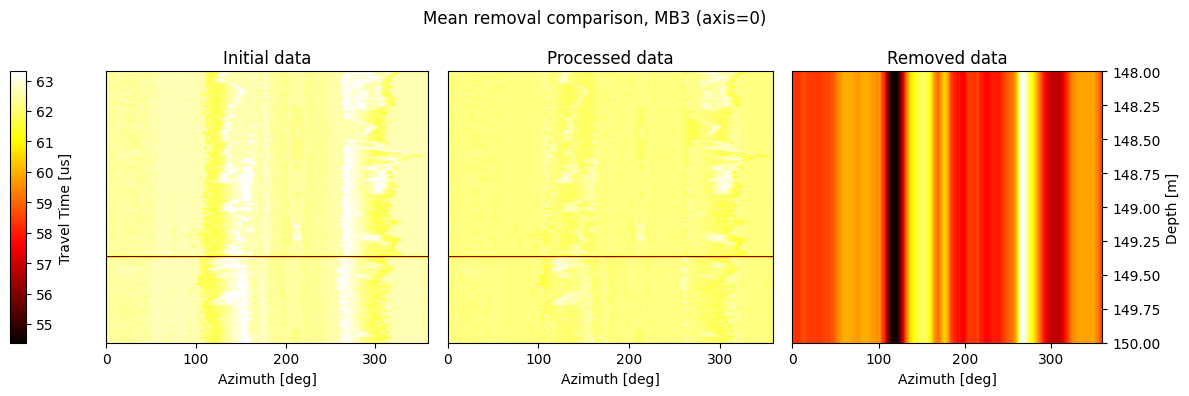

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: title={'center': 'Initial data'}, xlabel='Azimuth [deg]'>,
        <Axes: title={'center': 'Processed data'}, xlabel='Azimuth [deg]'>,
        <Axes: title={'center': 'Removed data'}, xlabel='Azimuth [deg]', ylabel='Depth [m]'>],
       dtype=object))

In [12]:
##plot a comparison of before and after the high-pass filtering
mean_removal_both, removed_data = remove_mean(data_subset_ATV_am, axis=0)

plot_comparison_am(data_subset_ATV_am,
                mean_removal_both,
                removed_data,   
                figure_limits=[0, 359, 150, 148], 
                title='Mean removal comparison, MB3 (axis =0)')
#same for travel time
mean_removal_both, removed_data = remove_mean(data_subset_ATV_tt, axis=0)

plot_comparison_tt(data_subset_ATV_tt,
                mean_removal_both,
                removed_data,   
                figure_limits=[0, 359, 150, 148], 
                title='Mean removal comparison, MB3 (axis=0)',
                cmap='hot')

### Load the OTV data

In [103]:
#Load OTV data and remove the empty measurements
file_name = files[7]
depth_OTV = get_depth_only(file_name=files[7],
               data_path=path_to_data)

depth_subset, data_subset, index = get_data_subset_from_depth_range(file_name=files[7],
                                                                    data_path=path_to_data,
                                                                    data_type='otv',
                                                                    depth_range=[95, 100])
data_subset = replace_empty_measurements(data_subset, 0)


/Users/palomaperritaz/deeplogger/venv/lib/python3.11/site-packages/pandas/core/internals/managers.py:1715: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr


### Plot the OTV data

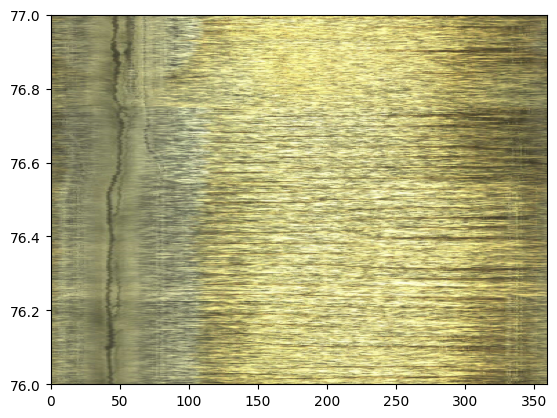

In [104]:

plt.imshow(data_subset, aspect='auto', extent=[0, 359, 76, 77])


In [2]:
import numpy as np
np.arctan(10)

1.4711276743037345

In [3]:
np.rad2deg(np.arctan(10))

84.28940686250036

28.61149714449487
27.46850285550513


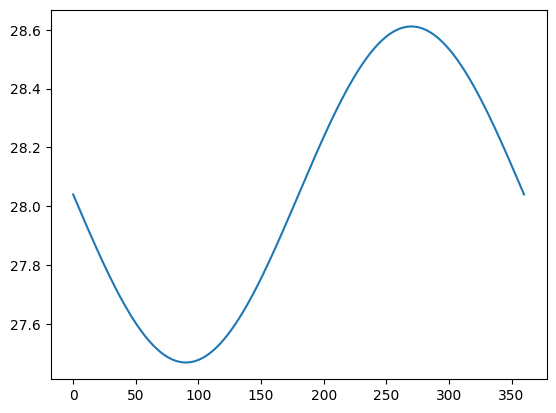

In [11]:
import matplotlib.pyplot as plt
degrees = np.linspace(0, 360, 360)
R = 0.1/2
depth = 28.04
azimuth = 90
dip = 85
label = depth + np.sin(np.deg2rad(degrees + 90 + azimuth))*R*np.tan(np.deg2rad(dip))
print(np.max(label))
print(np.min(label))
plt.plot(degrees, label)
plt.show()

In [16]:

from deeplogger.download_data import *   

#path_to_data, files = download_VALTER_borehole('MB1')

#if the files have already been downloaded use the command as following
path_to_data = '/Users/palomaperritaz/deeplogger/data/MB1/' #replace with your own path
files = os.listdir(path_to_data)
print(files)
# show the list of files in the folder as well as their number
print(len(files))
##Best File to analyse the data : 
file_atv_am =files[0] #am for the amplitude file to 295m of borehole MB1, the minimum depth of the file is 0.5 m.
file_atv_tt = files[4] #tt for the amplitude file to 295m of borehole MB1, the minimum depth of the file is 0.5 m. 
    ##sharp transition between 119.25 and 119.75m

['20191010_ATV_CB1_ampl_up3_to_295m.las', '20191010_OPTV_CB1_300m_up1.las', '20191010_ATV_ampl_CB1_up1_292_to_295m.las', '20191211_ATVSGAM_CB1_ampl_to_295m_up1.las', '20191010_ATV_CB1_TravelT_up3_to_295m.las', '20191211_ATVSGAM_CB1_TravelT_to_295m_up1.las', '20200125_ATV_ampl_300m_CB1_up_1_Falko.las', '20200125_ATV_travelT_300m_CB1_up_1_Falko.las', '20191010_ATV_TravelT_CB1_up1_292_to_295m.las']
9


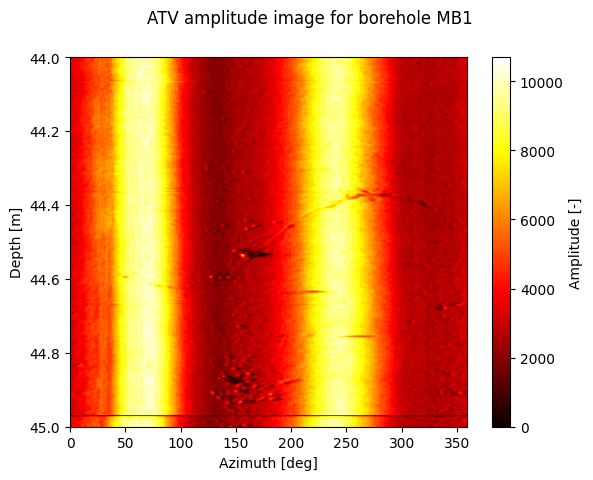

In [20]:
from deeplogger.importLASv3 import *
from deeplogger.image_processing import *
depth_ATV_am = get_depth_only(file_name=file_atv_am, #you can also just put the number of the data location in the files list, which is "files[10]" for the amplitude MB3 and "files[5]" for the travel time MB3
               data_path=path_to_data)

depth_subset_ATV_am, data_subset_ATV_am, index = get_data_subset_from_depth_range(file_name=file_atv_am,
                                                                    data_path=path_to_data,
                                                                    data_type='atv',
                                                                    depth_range=[44, 45])
#take-off the zero values within the data subset
data_subset_ATV_am = replace_empty_measurements(data_subset_ATV_am, 0)
from deeplogger.plotting import *
plt_ATV_am =plot_atv_am(data_subset_ATV_am, figure_limits=[0, 359,45, 44], cmap='hot', title= "ATV amplitude image for borehole MB1")


44.504374391302534
44.495625608697466


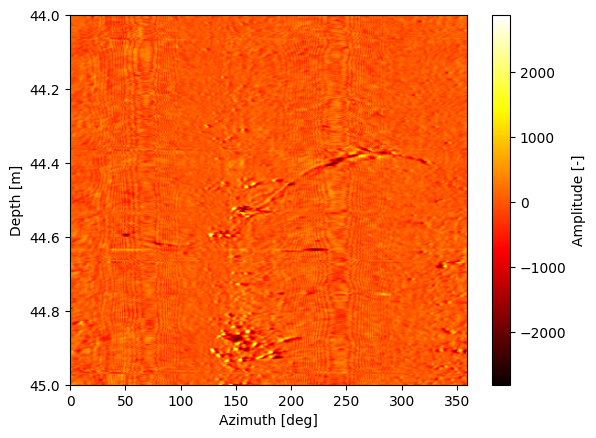

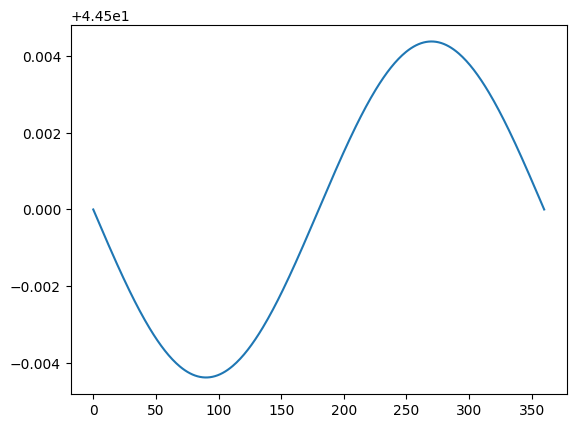

In [26]:
from deeplogger.image_processing import *
from deeplogger.plotting import *


# Apply SVD and plot the filtered data
# function returns the input data without the svd part and the svd part that is removed
# you can set the limits of the svd to remove by setting the low_s and high_s parameters
data_subset_svd_am = data_subset_svd_am, svd_decomp_am = remove_svd(data_subset_ATV_am, low_s=0, high_s=5)
# plot the data without the svd part

import matplotlib.pyplot as plt
degrees = np.linspace(0, 360, 360)
R = 0.1/2
depth = 44.5
azimuth = 90
dip = 5
label = depth + np.sin(np.deg2rad(degrees + 90 + azimuth))*R*np.tan(np.deg2rad(dip))
print(np.max(label))
print(np.min(label))
plot_atv_am(data_subset_svd_am, figure_limits=[0, 359,45, 44])
plt.plot(degrees, label)
plt.show()